In [1]:
#Simualting theft and building models

In [2]:
import pandas as pd

df_sim = pd.read_csv("../data/processed/clean_resampled.csv")

In [3]:
df_sim.head()


,x_Timestamp,meter,t_kWh,z_Avg Voltage (Volt),z_Avg Current (Amp),y_Freq (Hz),hour,day,month,day_of_week
0,2021-01-02 00:00:00,BR02,0.00850,253.9020,0.7160,50.0535,0,2,1,5
1,2021-01-02 01:00:00,BR02,0.00105,255.0410,0.1425,50.0170,1,2,1,5
2,2021-01-02 02:00:00,BR02,0.00100,255.4345,0.1335,49.9955,2,2,1,5
3,2021-01-02 03:00:00,BR02,0.00100,255.7510,0.1320,50.0160,3,2,1,5
4,2021-01-02 04:00:00,BR02,0.00100,255.8580,0.1300,50.0285,4,2,1,5


In [4]:
df_sim.shape

(165436, 10)

In [5]:
df_sim['x_Timestamp'] = pd.to_datetime(df_sim['x_Timestamp'])

In [8]:
df_sim['theft'] = 0

In [9]:
df_sim.head()

,x_Timestamp,meter,t_kWh,z_Avg Voltage (Volt),z_Avg Current (Amp),y_Freq (Hz),hour,day,month,day_of_week,theft
0,2021-01-02 00:00:00,BR02,0.00850,253.9020,0.7160,50.0535,0,2,1,5,0
1,2021-01-02 01:00:00,BR02,0.00105,255.0410,0.1425,50.0170,1,2,1,5,0
2,2021-01-02 02:00:00,BR02,0.00100,255.4345,0.1335,49.9955,2,2,1,5,0
3,2021-01-02 03:00:00,BR02,0.00100,255.7510,0.1320,50.0160,3,2,1,5,0
4,2021-01-02 04:00:00,BR02,0.00100,255.8580,0.1300,50.0285,4,2,1,5,0


In [10]:
#Selecting rows for theft (10%)
import numpy as np

# Total rows
n = len(df_sim)

# 10% of data
n_theft = int(0.10 * n)

# Randomly select indices
np.random.seed(42)  # for reproducibility
theft_indices = np.random.choice(df_sim.index, size=n_theft, replace=False)

In [11]:
len(theft_indices)

16543

In [12]:
meters = df_sim['meter'].unique()

np.random.seed(42)
selected_meters = np.random.choice(meters, size=int(0.2 * len(meters)), replace=False)

selected_meters

array(['BR50', 'BR29', 'BR22', 'BR37', 'BR15'], dtype=object)

In [13]:
import pandas as pd
import numpy as np

# Convert timestamp just to be safe
df_sim['x_Timestamp'] = pd.to_datetime(df_sim['x_Timestamp'])

# Store theft windows
theft_windows = []

np.random.seed(42)

for meter in selected_meters:
    
    meter_df = df_sim[df_sim['meter'] == meter]
    
    # Get unique timestamps
    timestamps = meter_df['x_Timestamp'].sort_values().unique()
    
    # Pick random start index
    start_idx = np.random.randint(0, len(timestamps) - 200)
    
    # Random duration (3 to 7 days → 72 to 168 hours)
    duration = np.random.randint(72, 168)
    
    start_time = timestamps[start_idx]
    end_time = timestamps[start_idx + duration]
    
    theft_windows.append((meter, start_time, end_time))

# View windows
theft_windows

[('BR50', Timestamp('2021-02-08 14:00:00'), Timestamp('2021-02-12 04:00:00')),
 ('BR29', Timestamp('2021-08-11 08:00:00'), Timestamp('2021-08-17 07:00:00')),
 ('BR22', Timestamp('2021-06-08 02:00:00'), Timestamp('2021-06-11 22:00:00')),
 ('BR37', Timestamp('2021-09-01 12:00:00'), Timestamp('2021-09-07 22:00:00')),
 ('BR15', Timestamp('2021-08-13 02:00:00'), Timestamp('2021-08-19 04:00:00'))]

In [ ]:
#Apply theft patterns

for meter, start, end in theft_windows:
    
    mask = (
        (df_sim['meter'] == meter) &
        (df_sim['x_Timestamp'] >= start) &
        (df_sim['x_Timestamp'] <= end)
    )
    
    # Load Suppression
    if meter == 'BR50':
        factor = np.random.uniform(0.3, 0.5)
        df_sim.loc[mask, 't_kWh'] *= factor
    
    # Flat Consumption
    elif meter == 'BR29':
        mean_val = df_sim.loc[mask, 't_kWh'].mean()
        df_sim.loc[mask, 't_kWh'] = mean_val
    
    # Intermittent Theft
    elif meter == 'BR22':
        idx = df_sim.loc[mask].index
        df_sim.loc[idx[::2], 't_kWh'] *= 0.4  # every alternate hour
    
    # Sudden Drop
    elif meter == 'BR37':
        df_sim.loc[mask, 't_kWh'] *= 0.2
    
    # Meter Bypass
    elif meter == 'BR15':
        df_sim.loc[mask, 't_kWh'] = df_sim.loc[mask, 't_kWh'] * 0.05

    # Mark theft
    df_sim.loc[mask, 'theft'] = 1

In [ ]:
#  created:

# Pattern	        Behavior
# Load suppression	reduced usage
# Flat	            constant usage
# Intermittent	    irregular pattern
# Sudden drop	    sharp fall
# Bypass	        near-zero

In [19]:
df_sim['theft'].value_counts()

theft
0    164810
1       626
Name: count, dtype: int64

In [20]:
df_sim = df_sim.copy()
df_sim['theft'] = 0

In [22]:
df_sim.head()

,x_Timestamp,meter,t_kWh,z_Avg Voltage (Volt),z_Avg Current (Amp),y_Freq (Hz),hour,day,month,day_of_week,theft
0,2021-01-02 00:00:00,BR02,0.00850,253.9020,0.7160,50.0535,0,2,1,5,0
1,2021-01-02 01:00:00,BR02,0.00105,255.0410,0.1425,50.0170,1,2,1,5,0
2,2021-01-02 02:00:00,BR02,0.00100,255.4345,0.1335,49.9955,2,2,1,5,0
3,2021-01-02 03:00:00,BR02,0.00100,255.7510,0.1320,50.0160,3,2,1,5,0
4,2021-01-02 04:00:00,BR02,0.00100,255.8580,0.1300,50.0285,4,2,1,5,0


In [21]:
theft_windows = []

np.random.seed(42)

for meter in selected_meters:
    
    meter_df = df_sim[df_sim['meter'] == meter]
    timestamps = meter_df['x_Timestamp'].sort_values().unique()
    
    # 5 to 7 windows per meter
    n_windows = np.random.randint(5, 8)
    
    for _ in range(n_windows):
        
        start_idx = np.random.randint(0, len(timestamps) - 300)
        
        # 7 to 15 days → 168 to 360 hours
        duration = np.random.randint(168, 360)
        
        start_time = timestamps[start_idx]
        end_time = timestamps[start_idx + duration]
        
        theft_windows.append((meter, start_time, end_time))

len(theft_windows)

32

In [23]:
len(theft_windows)

32

In [24]:
for meter, start, end in theft_windows:
    
    mask = (
        (df_sim['meter'] == meter) &
        (df_sim['x_Timestamp'] >= start) &
        (df_sim['x_Timestamp'] <= end)
    )
    
    # Randomly assign a theft type for each window
    theft_type = np.random.choice(['load', 'flat', 'intermittent', 'drop', 'bypass'])
    
    # Load Suppression
    if theft_type == 'load':
        factor = np.random.uniform(0.3, 0.5)
        df_sim.loc[mask, 't_kWh'] *= factor
    
    # Flat Consumption
    elif theft_type == 'flat':
        mean_val = df_sim.loc[mask, 't_kWh'].mean()
        df_sim.loc[mask, 't_kWh'] = mean_val
    
    # Intermittent Theft
    elif theft_type == 'intermittent':
        idx = df_sim.loc[mask].index
        df_sim.loc[idx[::2], 't_kWh'] *= 0.4
    
    # Sudden Drop
    elif theft_type == 'drop':
        df_sim.loc[mask, 't_kWh'] *= 0.2
    
    # Meter Bypass
    elif theft_type == 'bypass':
        df_sim.loc[mask, 't_kWh'] *= 0.05
    
    # Mark theft
    df_sim.loc[mask, 'theft'] = 1

In [25]:
df_sim['theft'].value_counts()

theft
0    158036
1      7400
Name: count, dtype: int64

In [28]:
#adding more windows for theft
extra_windows = []

for meter in selected_meters:
    
    meter_df = df_sim[df_sim['meter'] == meter]
    timestamps = meter_df['x_Timestamp'].sort_values().unique()
    
    # Add 2–3 more windows
    n_extra = np.random.randint(2, 4)
    
    for _ in range(n_extra):
        
        start_idx = np.random.randint(0, len(timestamps) - 300)
        duration = np.random.randint(168, 360)
        
        start_time = timestamps[start_idx]
        end_time = timestamps[start_idx + duration]
        
        extra_windows.append((meter, start_time, end_time))

In [29]:
for meter, start, end in extra_windows:
    
    mask = (
        (df_sim['meter'] == meter) &
        (df_sim['x_Timestamp'] >= start) &
        (df_sim['x_Timestamp'] <= end)
    )
    
    theft_type = np.random.choice(['load', 'flat', 'intermittent', 'drop', 'bypass'])
    
    if theft_type == 'load':
        df_sim.loc[mask, 't_kWh'] *= np.random.uniform(0.3, 0.5)
    
    elif theft_type == 'flat':
        mean_val = df_sim.loc[mask, 't_kWh'].mean()
        df_sim.loc[mask, 't_kWh'] = mean_val
    
    elif theft_type == 'intermittent':
        idx = df_sim.loc[mask].index
        df_sim.loc[idx[::2], 't_kWh'] *= 0.4
    
    elif theft_type == 'drop':
        df_sim.loc[mask, 't_kWh'] *= 0.2
    
    elif theft_type == 'bypass':
        df_sim.loc[mask, 't_kWh'] *= 0.05
    
    df_sim.loc[mask, 'theft'] = 1

In [30]:
df_sim['theft'].value_counts()

theft
0    154732
1     10704
Name: count, dtype: int64

In [31]:
remaining_meters = list(set(df_sim['meter'].unique()) - set(selected_meters))

np.random.seed(42)
new_meters = np.random.choice(remaining_meters, size=3, replace=False)

new_meters

array(['BR18', 'BR12', 'BR05'], dtype='<U4')

In [32]:
new_windows = []

for meter in new_meters:
    
    meter_df = df_sim[df_sim['meter'] == meter]
    timestamps = meter_df['x_Timestamp'].sort_values().unique()
    
    # 4–10 windows per new meter
    n_windows = np.random.randint(4, 11)
    
    for _ in range(n_windows):
        
        start_idx = np.random.randint(0, len(timestamps) - 300)
        duration = np.random.randint(168, 360)  # 7–15 days
        
        start_time = timestamps[start_idx]
        end_time = timestamps[start_idx + duration]
        
        new_windows.append((meter, start_time, end_time))

len(new_windows)

25

In [36]:
#Apply theft on NEW meters ..new windows
for meter, start, end in new_windows:
    
    mask = (
        (df_sim['meter'] == meter) &
        (df_sim['x_Timestamp'] >= start) &
        (df_sim['x_Timestamp'] <= end)
    )
    
    theft_type = np.random.choice(['load', 'flat', 'intermittent', 'drop', 'bypass'])
    
    if theft_type == 'load':
        df_sim.loc[mask, 't_kWh'] *= np.random.uniform(0.3, 0.5)
    
    elif theft_type == 'flat':
        mean_val = df_sim.loc[mask, 't_kWh'].mean()
        df_sim.loc[mask, 't_kWh'] = mean_val
    
    elif theft_type == 'intermittent':
        idx = df_sim.loc[mask].index
        df_sim.loc[idx[::2], 't_kWh'] *= 0.4
    
    elif theft_type == 'drop':
        df_sim.loc[mask, 't_kWh'] *= 0.2
    
    elif theft_type == 'bypass':
        df_sim.loc[mask, 't_kWh'] *= 0.05
    
    df_sim.loc[mask, 'theft'] = 1

In [37]:
df_sim['theft'].value_counts()

theft
0    150601
1     14835
Name: count, dtype: int64

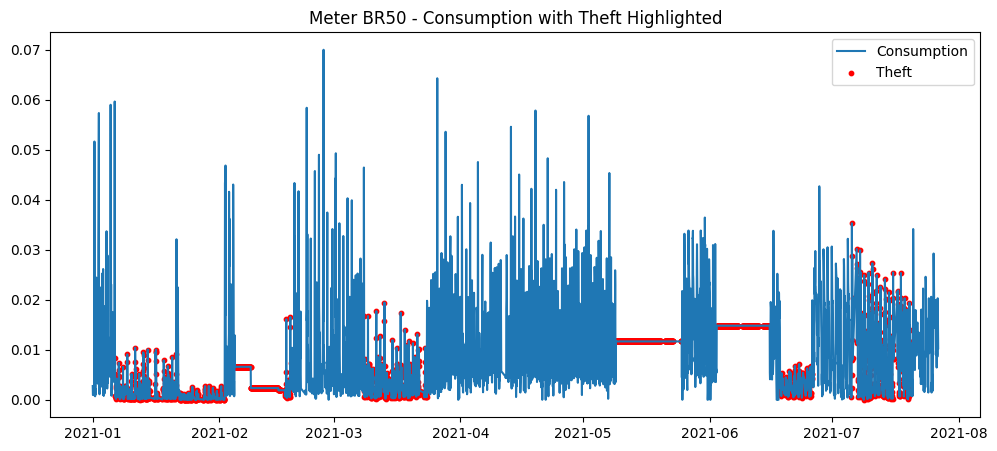

In [41]:
import matplotlib.pyplot as plt

# pick a meter that has theft
meter = selected_meters[0]   # e.g. BR50

temp = df_sim[df_sim['meter'] == meter]

plt.figure(figsize=(12,5))

plt.plot(temp['x_Timestamp'], temp['t_kWh'], label='Consumption')

# highlight theft points
theft_points = temp[temp['theft'] == 1]

plt.scatter(theft_points['x_Timestamp'], theft_points['t_kWh'], 
            color='red', s=10, label='Theft')

plt.title(f"Meter {meter} - Consumption with Theft Highlighted")
plt.legend()
plt.show()

In [ ]:
# (objective analysis)
# ✅ 1. Clear separation between normal and theft
# Blue → normal consumption
# Red → theft

# 👉 Red points are not random → good ✔

# ✅ 2. Continuous theft regions (VERY IMPORTANT)
# You can see clusters of red points
# Not scattered randomly

# 👉 This confirms:

# ✔ Time-window based simulation worked correctly

# ✅ 3. Different theft behaviors visible
# 🔹 Near-zero segments
# Red points close to 0
# 👉 Meter bypass / drop
# 🔹 Flat horizontal segments
# Straight red lines
# 👉 Flat consumption pattern
# 🔹 Reduced noisy segments
# Same pattern but lower amplitude
# 👉 Load suppression
# ⚠️ 4. One minor observation (not a problem)

# Some areas look like:

# Red points overlapping with blue noise

# 👉 That’s because:

# You kept original variability (good)
# Only scaled values

# 👉 This is actually more realistic, not an issue

# 🎯 Verdict
# Criteria	Status
# Temporal continuity	✅
# Pattern realism	✅
# Variety of behaviors	✅
# Non-random distribution	✅


# “The simulated theft patterns show realistic temporal continuity,
#  including sustained drops, flat consumption, and intermittent reductions, closely mimicking real-world tampering behavior.”

In [42]:
#final simulated dataset
df_sim.to_csv("../data/processed/simulated_theft_data.csv", index=False)